# Mount Goole Drive for Yelp Dataset

In [1]:
!pip install vaderSentiment

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 4.2 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

business_path = "/content/drive/MyDrive/Colab Notebooks/CMPSC445/yelp_academic_dataset_business.json"
review_path = "/content/drive/MyDrive/Colab Notebooks/CMPSC445/yelp_academic_dataset_review.json"

Mounted at /content/drive


In [3]:
import json

pa_business_ids = set()
pa_business = {}

with open(business_path, "r") as f:
    for line in f:
        b = json.loads(line)

        if b.get("state") == "PA" and "Restaurants" in str(b.get("categories")):
            pa_business_ids.add(b["business_id"])

            pa_business[b["business_id"]] = {
                "name": b.get("name"),
                "city": b.get("city"),
                "categories": b.get("categories"),
                "stars": b.get("stars", 0),
                "review_count": b.get("review_count", 0)
            }

print("Total PA Restaurants:", len(pa_business_ids))

Total PA Restaurants: 12641


In [4]:
reviews = []

MAX_REVIEWS = 200000  # adjust if needed

with open(review_path, "r") as f:
    for i, line in enumerate(f):
        r = json.loads(line)

        if r["business_id"] in pa_business_ids:
            reviews.append({
                "business_id": r["business_id"],
                "text": r["text"],
                "stars": r["stars"]
            })

        if len(reviews) >= MAX_REVIEWS:
            break

print("Collected Reviews:", len(reviews))

Collected Reviews: 200000


# Convert to dataframe and merge

In [5]:
import pandas as pd

# Convert business dict to DataFrame
business_df = pd.DataFrame.from_dict(pa_business, orient="index")
business_df.reset_index(inplace=True)
business_df.rename(columns={"index": "business_id"}, inplace=True)

# Convert reviews to DataFrame
reviews_df = pd.DataFrame(reviews)

# Merge datasets
merged_df = reviews_df.merge(business_df, on="business_id")

print("Merged shape:", merged_df.shape)
merged_df.head()

Merged shape: (200000, 8)


,business_id,text,stars_x,name,city,categories,stars_y,review_count
0,XQfwVwDr-v0ZS3_CbbE5Xw,"If you decide to eat here, just be aware it is...",3.0,Turning Point of North Wales,North Wales,"Restaurants, Breakfast & Brunch, Food, Juice B...",3.0,169
1,kxX2SOes4o-D3ZQBkiMRfA,"Wow! Yummy, different, delicious. Our favo...",5.0,Zaika,Philadelphia,"Halal, Pakistani, Restaurants, Indian",4.0,181
2,04UD14gamNjLY0IDYVhHJg,I am a long term frequent customer of this est...,1.0,Dmitri's,Philadelphia,"Mediterranean, Restaurants, Seafood, Greek",4.0,273
3,LHSTtnW3YHCeUkRDGyJOyw,Amazingly amazing wings and homemade bleu chee...,5.0,Fries Rebellion,Quakertown,"Beer Bar, Bars, American (New), Gastropubs, Re...",3.5,103
4,RZtGWDLCAtuipwaZ-UfjmQ,Good food--loved the gnocchi with marinara\nth...,4.0,LaScala's,Philadelphia,"Pizza, Restaurants, Italian, Salad",3.5,367


# Sentiment analysis with VADER

In [6]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

def get_sentiment(text):
    return analyzer.polarity_scores(text)["compound"]

# Apply sentiment
merged_df["sentiment"] = merged_df["text"].apply(get_sentiment)

merged_df[["text", "sentiment"]].head()

,text,sentiment
0,"If you decide to eat here, just be aware it is...",0.8597
1,"Wow! Yummy, different, delicious. Our favo...",0.9588
2,I am a long term frequent customer of this est...,0.7117
3,Amazingly amazing wings and homemade bleu chee...,0.9706
4,Good food--loved the gnocchi with marinara\nth...,0.7843


# Aggregate to Restaurant level

In [7]:
agg_df = merged_df.groupby("business_id").agg({
    "sentiment": "mean",
    "stars_x": "mean",  # review stars
    "stars_y": "first", # business rating
    "review_count": "first",
    "name": "first",
    "city": "first"
}).reset_index()

# Rename columns
agg_df.rename(columns={
    "stars_x": "avg_review_rating",
    "stars_y": "business_rating"
}, inplace=True)

agg_df.head()

,business_id,sentiment,avg_review_rating,business_rating,review_count,name,city
0,--ZVrH2X2QXBFdCilbirsw,0.810769,4.722222,4.5,32,Chris's Sandwich Shop,Ardmore
1,-0TffRSXXIlBYVbb5AwfTg,0.861192,4.342893,4.5,1097,IndeBlue Modern Indian Food & Spirits,Philadelphia
2,-3725FZiIIYdwQtM4MKEIA,0.060867,1.888889,1.5,20,Domino's Pizza,Glen Mills
3,-3IOd5YntpkbK6RwT3HYtA,0.577181,3.806452,3.5,179,Ice House Steaks & Pizza,Pottstown
4,-7GDqSUaXrpC8Ql7nDBxWA,0.796933,4.221053,4.0,92,B2 Bluefin,Bala Cynwyd


# feature engineering

In [8]:
import numpy as np

# Log transform review count
agg_df["log_review_count"] = np.log1p(agg_df["review_count"])

# Drop missing values
agg_df = agg_df.dropna()

agg_df.head()

,business_id,sentiment,avg_review_rating,business_rating,review_count,name,city,log_review_count
0,--ZVrH2X2QXBFdCilbirsw,0.810769,4.722222,4.5,32,Chris's Sandwich Shop,Ardmore,3.496508
1,-0TffRSXXIlBYVbb5AwfTg,0.861192,4.342893,4.5,1097,IndeBlue Modern Indian Food & Spirits,Philadelphia,7.001246
2,-3725FZiIIYdwQtM4MKEIA,0.060867,1.888889,1.5,20,Domino's Pizza,Glen Mills,3.044522
3,-3IOd5YntpkbK6RwT3HYtA,0.577181,3.806452,3.5,179,Ice House Steaks & Pizza,Pottstown,5.192957
4,-7GDqSUaXrpC8Ql7nDBxWA,0.796933,4.221053,4.0,92,B2 Bluefin,Bala Cynwyd,4.532599


In [9]:
from sklearn.model_selection import train_test_split

# Features and target
X = agg_df[["sentiment", "log_review_count"]]
y = agg_df["business_rating"]

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape)

Train size: (2040, 2)


# Train model with Random Forest

In [10]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

# Evaluate the model with RMSE and MAE

In [11]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print("RMSE:", rmse)
print("MAE:", mae)

RMSE: 0.5087837075386273
MAE: 0.38180039138943245


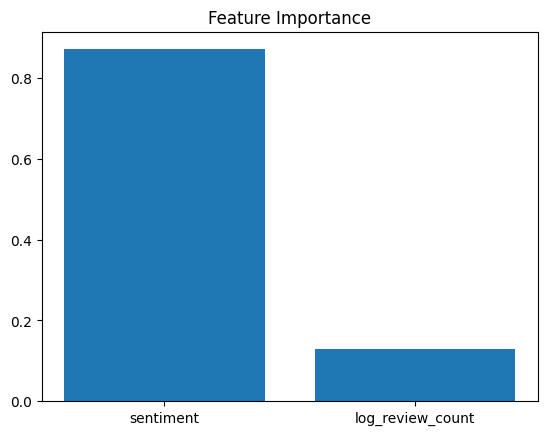

In [12]:
import matplotlib.pyplot as plt

features = X.columns
importances = model.feature_importances_

plt.bar(features, importances)
plt.title("Feature Importance")
plt.show()

# Save model to Drive

In [13]:
import pickle

# Save model
with open("/content/drive/MyDrive/Colab Notebooks/CMPSC445/model1.pkl", "wb") as f:
    pickle.dump(model, f)

# Save cleaned dataset
agg_df.to_csv("/content/drive/MyDrive/Colab Notebooks/CMPSC445/restaurants_clean.csv", index=False)

print("Saved model and dataset!")

Saved model and dataset!


# Test model

In [14]:
import pickle
import pandas as pd

with open("/content/drive/MyDrive/Colab Notebooks/CMPSC445/model1.pkl", "rb") as f:
    model = pickle.load(f)
data_path = "/content/drive/MyDrive/Colab Notebooks/CMPSC445/restaurants_clean.csv"

df = pd.read_csv(data_path)

df.head()

,business_id,sentiment,avg_review_rating,business_rating,review_count,name,city,log_review_count
0,--ZVrH2X2QXBFdCilbirsw,0.810769,4.722222,4.5,32,Chris's Sandwich Shop,Ardmore,3.496508
1,-0TffRSXXIlBYVbb5AwfTg,0.861192,4.342893,4.5,1097,IndeBlue Modern Indian Food & Spirits,Philadelphia,7.001246
2,-3725FZiIIYdwQtM4MKEIA,0.060867,1.888889,1.5,20,Domino's Pizza,Glen Mills,3.044522
3,-3IOd5YntpkbK6RwT3HYtA,0.577181,3.806452,3.5,179,Ice House Steaks & Pizza,Pottstown,5.192957
4,-7GDqSUaXrpC8Ql7nDBxWA,0.796933,4.221053,4.0,92,B2 Bluefin,Bala Cynwyd,4.532599


# Test single prediction

In [15]:
sample = df.iloc[0]

X_test = [[
    sample["sentiment"],
    sample["log_review_count"]
]]

pred = model.predict(X_test)

print("Predicted rating:", pred[0])
print("Actual rating:", sample["business_rating"])

Predicted rating: 4.435
Actual rating: 4.5


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


# Test all restaurants for top ten



In [16]:
X_all = df[["sentiment", "log_review_count"]]

df["predicted_score"] = model.predict(X_all)

top10 = df.sort_values("predicted_score", ascending=False).head(10)

top10[["name", "city", "predicted_score", "business_rating"]]

,name,city,predicted_score,business_rating
256,Maliwan,Philadelphia,4.870,5.0
856,Polka Deli Inc,Philadelphia,4.860,5.0
1617,Castellino's,Philadelphia,4.855,5.0
2194,Poke Bros,West Chester,4.855,5.0
379,Bold Coffee Bar,Philadelphia,4.855,5.0
1653,El Guero Mexican Food Truck,Philadelphia,4.850,5.0
130,Pala'a Latin American Seafood,Ardmore,4.840,5.0
1080,New China,Philadelphia,4.830,3.5
1752,Rasavat,Philadelphia,4.820,5.0
1547,Otolith Sustainable Seafood,Philadelphia,4.815,5.0


In [17]:
!pip install flask pyngrok vaderSentiment --quiet

In [18]:
import os

os.makedirs("/content/templates", exist_ok=True)
os.makedirs("/content/static", exist_ok=True)

# Write base.html
with open("/content/templates/base.html", "w") as f:
    f.write("""<!DOCTYPE html>
<html lang="en">
<head>
  <meta charset="UTF-8" />
  <meta name="viewport" content="width=device-width, initial-scale=1.0" />
  <title>{% block title %}Best in PA — Restaurant Finder{% endblock %}</title>
  <link rel="preconnect" href="https://fonts.googleapis.com">
  <link href="https://fonts.googleapis.com/css2?family=Playfair+Display:wght@700;900&family=DM+Sans:wght@300;400;500&display=swap" rel="stylesheet">
  <script src="https://cdn.jsdelivr.net/npm/chart.js@4.4.0/dist/chart.umd.min.js"></script>
  <link rel="stylesheet" href="{{ url_for('static', filename='style.css') }}">
</head>
<body>
  <header class="site-header">
    <a href="/" class="logo">
      <span class="logo-star">★</span> Best in PA
    </a>
    <span class="logo-sub">Restaurant Intelligence</span>
  </header>

  <main>
    {% block content %}{% endblock %}
  </main>

  <footer>
    <p>CMPSC 445 &mdash; Machine Learning Final Project &middot; Powered by Yelp Open Dataset</p>
  </footer>
</body>
</html>""")

# Write index.html
with open("/content/templates/index.html", "w") as f:
    f.write("""{% extends "base.html" %}
{% block content %}

<section class="hero">
  <div class="hero-text">
    <h1>Find Pennsylvania's<br><em>Best Restaurants</em></h1>
    <p class="hero-sub">
      Our Random Forest model ranks PA restaurants using <strong>sentiment analysis</strong>,
      review volume, and star ratings from the Yelp Open Dataset.
    </p>
  </div>

  <div class="search-card">
    {% if error %}
      <p class="error-msg">⚠ {{ error }}</p>
    {% endif %}

    <form action="/results" method="POST">
      <div class="form-group">
        <label for="city">City</label>
        <select name="city" id="city">
          <option value="">— All of Pennsylvania —</option>
          {% for c in cities %}
            <option value="{{ c }}">{{ c }}</option>
          {% endfor %}
        </select>
      </div>

      <div class="form-group">
        <label for="top_n">Show top</label>
        <select name="top_n" id="top_n">
          <option value="5">5 restaurants</option>
          <option value="10" selected>10 restaurants</option>
          <option value="20">20 restaurants</option>
          <option value="50">50 restaurants</option>
        </select>
      </div>

      <button type="submit" class="btn-primary">Rank Restaurants →</button>
    </form>
  </div>
</section>

<section class="how-it-works">
  <h2>How It Works</h2>
  <div class="steps">
    <div class="step">
      <span class="step-num">01</span>
      <h3>Sentiment Analysis</h3>
      <p>VADER NLP scores every review's tone, from strongly negative to strongly positive.</p>
    </div>
    <div class="step">
      <span class="step-num">02</span>
      <h3>Feature Engineering</h3>
      <p>Review counts are log-transformed and aggregated per restaurant alongside star averages.</p>
    </div>
    <div class="step">
      <span class="step-num">03</span>
      <h3>Random Forest</h3>
      <p>A 100-tree Random Forest Regressor predicts each restaurant's score and ranks them.</p>
    </div>
  </div>
</section>

{% endblock %}""")

# Write results.html
with open("/content/templates/results.html", "w") as f:
    f.write("""{% extends "base.html" %}
{% block title %}Results — {{ city }}{% endblock %}

{% block content %}

<div class="results-header">
  <div>
    <h1>Top {{ top_n }} Restaurants</h1>
    <p class="results-sub">Ranked by predicted score &mdash; <strong>{{ city }}</strong></p>
  </div>
  <a href="/" class="btn-secondary">← New Search</a>
</div>

<!-- ── Rankings Table ──────────────────────────────────────────────────── -->
<section class="section">
  <h2 class="section-title">Rankings</h2>
  <div class="table-wrap">
    <table>
      <thead>
        <tr>
          <th>#</th>
          <th>Restaurant</th>
          <th>City</th>
          <th>Predicted Score</th>
          <th>Avg Review ★</th>
          <th>Sentiment</th>
          <th>Reviews</th>
        </tr>
      </thead>
      <tbody>
        {% for r in restaurants %}
        <tr class="{{ 'top-three' if loop.index <= 3 }}">
          <td class="rank">
            {% if loop.index == 1 %}🥇
            {% elif loop.index == 2 %}🥈
            {% elif loop.index == 3 %}🥉
            {% else %}{{ loop.index }}{% endif %}
          </td>
          <td class="rest-name">{{ r.name }}</td>
          <td>{{ r.city }}</td>
          <td class="score">{{ "%.3f"|format(r.predicted_score) }}</td>
          <td>{{ "%.2f"|format(r.avg_review_rating) }}</td>
          <td class="{{ 'pos' if r.sentiment > 0 else 'neg' }}">
            {{ "%.3f"|format(r.sentiment) }}
          </td>
          <td>{{ r.review_count | int }}</td>
        </tr>
        {% endfor %}
      </tbody>
    </table>
  </div>
</section>

<!-- ── Charts Grid ─────────────────────────────────────────────────────── -->
<section class="section">
  <h2 class="section-title">Model Visualizations</h2>
  <div class="charts-grid">

    <!-- Bar: top restaurants -->
    <div class="chart-card wide">
      <h3>Predicted Scores — Top {{ top_n }}</h3>
      <p class="chart-desc">Each bar represents the Random Forest's predicted rating for that restaurant.</p>
      <canvas id="barChart"></canvas>
    </div>

    <!-- Feature importance -->
    <div class="chart-card">
      <h3>Feature Importance</h3>
      <p class="chart-desc">How much each feature contributes to the model's predictions.</p>
      <canvas id="featChart"></canvas>
    </div>

    <!-- Score distribution -->
    <div class="chart-card">
      <h3>Score Distribution</h3>
      <p class="chart-desc">Histogram of predicted scores across all restaurants in {{ city }}.</p>
      <canvas id="distChart"></canvas>
    </div>

    <!-- Scatter: sentiment vs score -->
    <div class="chart-card wide">
      <h3>Sentiment vs Predicted Score</h3>
      <p class="chart-desc">Each point is one restaurant. Higher sentiment generally correlates with a higher predicted score.</p>
      <canvas id="scatterChart"></canvas>
    </div>

  </div>
</section>

<!-- ── Chart.js Scripts ────────────────────────────────────────────────── -->
<script>
  const GOLD   = "#c9a84c";
  const AMBER  = "#e8c56d";
  const DARK   = "#1a1a18";
  const MUTED  = "rgba(201,168,76,0.15)";
  const GRID   = "rgba(255,255,255,0.07)";
  const LABEL  = "#c8c4b4";

  Chart.defaults.color = LABEL;
  Chart.defaults.font.family = "'DM Sans', sans-serif";

  // 1. Bar chart
  new Chart(document.getElementById("barChart"), {
    type: "bar",
    data: {
      labels: {{ bar_labels | tojson }},
      datasets: [{
        label: "Predicted Score",
        data: {{ bar_scores | tojson }},
        backgroundColor: {{ bar_scores | tojson }}.map((v, i) =>
          i < 3 ? GOLD : AMBER + "99"
        ),
        borderRadius: 4,
      }]
    },
    options: {
      responsive: true,
      plugins: { legend: { display: false } },
      scales: {
        x: { ticks: { maxRotation: 35, font: { size: 11 } }, grid: { color: GRID } },
        y: { min: 0, max: 5, grid: { color: GRID } }
      }
    }
  });

  // 2. Feature importance (horizontal bar)
  new Chart(document.getElementById("featChart"), {
    type: "bar",
    data: {
      labels: {{ feat_names | tojson }},
      datasets: [{
        label: "Importance",
        data: {{ feat_importances | tojson }},
        backgroundColor: [GOLD, AMBER, "#a07830"],
        borderRadius: 4,
      }]
    },
    options: {
      indexAxis: "y",
      responsive: true,
      plugins: { legend: { display: false } },
      scales: {
        x: { grid: { color: GRID } },
        y: { grid: { color: GRID } }
      }
    }
  });

  // 3. Score distribution histogram
  new Chart(document.getElementById("distChart"), {
    type: "bar",
    data: {
      labels: {{ dist_labels | tojson }},
      datasets: [{
        label: "# Restaurants",
        data: {{ dist_counts | tojson }},
        backgroundColor: MUTED,
        borderColor: GOLD,
        borderWidth: 1,
        borderRadius: 2,
      }]
    },
    options: {
      responsive: true,
      plugins: { legend: { display: false } },
      scales: {
        x: { grid: { color: GRID } },
        y: { grid: { color: GRID } }
      }
    }
  });

  // 4. Scatter: sentiment vs score
  new Chart(document.getElementById("scatterChart"), {
    type: "scatter",
    data: {
      datasets: [{
        label: "Restaurant",
        data: {{ scatter_data | tojson }},
        backgroundColor: GOLD + "88",
        pointRadius: 4,
        pointHoverRadius: 7,
      }]
    },
    options: {
      responsive: true,
      plugins: {
        legend: { display: false },
        tooltip: {
          callbacks: {
            label: ctx => {
              const d = ctx.raw;
              return `${d.name} | Sentiment: ${d.x}, Score: ${d.y}`;
            }
          }
        }
      },
      scales: {
        x: {
          title: { display: true, text: "Avg Sentiment Score", color: LABEL },
          grid: { color: GRID }
        },
        y: {
          title: { display: true, text: "Predicted Score", color: LABEL },
          min: 0, max: 5,
          grid: { color: GRID }
        }
      }
    }
  });
</script>

{% endblock %}""")

# Write style.css
with open("/content/static/style.css", "w") as f:
    f.write("""/* ── Variables ──────────────────────────────────────────────────────────── */
:root {
  --bg:       #111110;
  --surface:  #1c1c1a;
  --border:   #2e2e2b;
  --gold:     #c9a84c;
  --gold-lt:  #e8c56d;
  --text:     #e8e4d8;
  --muted:    #8a8678;
  --pos:      #7dba84;
  --neg:      #c96c6c;
  --radius:   10px;
}

/* ── Reset / Base ───────────────────────────────────────────────────────── */
*, *::before, *::after { box-sizing: border-box; margin: 0; padding: 0; }

body {
  background: var(--bg);
  color: var(--text);
  font-family: 'DM Sans', sans-serif;
  font-weight: 300;
  min-height: 100vh;
  display: flex;
  flex-direction: column;
}

main { flex: 1; }

a { color: var(--gold); text-decoration: none; }
a:hover { color: var(--gold-lt); }

/* ── Header ─────────────────────────────────────────────────────────────── */
.site-header {
  display: flex;
  align-items: baseline;
  gap: 1rem;
  padding: 1.25rem 2.5rem;
  border-bottom: 1px solid var(--border);
  background: var(--surface);
}

.logo {
  font-family: 'Playfair Display', serif;
  font-size: 1.35rem;
  font-weight: 700;
  color: var(--gold);
  letter-spacing: 0.01em;
}

.logo-star { margin-right: 0.2em; }

.logo-sub {
  font-size: 0.78rem;
  letter-spacing: 0.12em;
  text-transform: uppercase;
  color: var(--muted);
}

/* ── Hero ───────────────────────────────────────────────────────────────── */
.hero {
  display: flex;
  gap: 4rem;
  align-items: flex-start;
  max-width: 1100px;
  margin: 5rem auto 4rem;
  padding: 0 2rem;
}

.hero-text { flex: 1; }

.hero-text h1 {
  font-family: 'Playfair Display', serif;
  font-size: clamp(2.4rem, 5vw, 3.8rem);
  line-height: 1.1;
  font-weight: 900;
  letter-spacing: -0.02em;
  margin-bottom: 1.25rem;
}

.hero-text h1 em {
  color: var(--gold);
  font-style: normal;
}

.hero-sub {
  font-size: 1.05rem;
  line-height: 1.7;
  color: var(--muted);
  max-width: 420px;
}

/* ── Search Card ────────────────────────────────────────────────────────── */
.search-card {
  background: var(--surface);
  border: 1px solid var(--border);
  border-radius: var(--radius);
  padding: 2rem 2.25rem;
  width: 320px;
  flex-shrink: 0;
}

.form-group { margin-bottom: 1.25rem; }

.form-group label {
  display: block;
  font-size: 0.78rem;
  letter-spacing: 0.1em;
  text-transform: uppercase;
  color: var(--muted);
  margin-bottom: 0.5rem;
}

select {
  width: 100%;
  background: var(--bg);
  border: 1px solid var(--border);
  color: var(--text);
  padding: 0.65rem 0.9rem;
  border-radius: 6px;
  font-family: inherit;
  font-size: 0.95rem;
  cursor: pointer;
  appearance: none;
  background-image: url("data:image/svg+xml,%3Csvg xmlns='http://www.w3.org/2000/svg' width='12' height='8' viewBox='0 0 12 8'%3E%3Cpath d='M1 1l5 5 5-5' stroke='%238a8678' stroke-width='1.5' fill='none'/%3E%3C/svg%3E");
  background-repeat: no-repeat;
  background-position: right 0.9rem center;
  padding-right: 2.2rem;
}

select:focus { outline: 1px solid var(--gold); border-color: var(--gold); }

.btn-primary {
  width: 100%;
  background: var(--gold);
  color: #111;
  border: none;
  padding: 0.85rem 1.5rem;
  border-radius: 6px;
  font-family: inherit;
  font-size: 0.95rem;
  font-weight: 500;
  cursor: pointer;
  letter-spacing: 0.03em;
  transition: background 0.18s, transform 0.1s;
  margin-top: 0.5rem;
}

.btn-primary:hover { background: var(--gold-lt); transform: translateY(-1px); }

.btn-secondary {
  background: transparent;
  border: 1px solid var(--border);
  color: var(--muted);
  padding: 0.6rem 1.2rem;
  border-radius: 6px;
  font-family: inherit;
  font-size: 0.88rem;
  cursor: pointer;
  transition: border-color 0.18s, color 0.18s;
  white-space: nowrap;
}

.btn-secondary:hover { border-color: var(--gold); color: var(--gold); }

.error-msg {
  background: rgba(201, 108, 108, 0.12);
  border: 1px solid #c96c6c44;
  border-radius: 6px;
  padding: 0.75rem 1rem;
  font-size: 0.9rem;
  color: var(--neg);
  margin-bottom: 1.25rem;
}

/* ── How It Works ───────────────────────────────────────────────────────── */
.how-it-works {
  max-width: 1100px;
  margin: 0 auto 5rem;
  padding: 0 2rem;
}

.how-it-works h2 {
  font-family: 'Playfair Display', serif;
  font-size: 1.6rem;
  margin-bottom: 2rem;
  color: var(--muted);
  font-weight: 700;
}

.steps {
  display: grid;
  grid-template-columns: repeat(auto-fit, minmax(240px, 1fr));
  gap: 1.5rem;
}

.step {
  background: var(--surface);
  border: 1px solid var(--border);
  border-radius: var(--radius);
  padding: 1.75rem;
}

.step-num {
  font-family: 'Playfair Display', serif;
  font-size: 2.5rem;
  font-weight: 900;
  color: var(--border);
  display: block;
  line-height: 1;
  margin-bottom: 0.75rem;
}

.step h3 {
  font-size: 1rem;
  font-weight: 500;
  color: var(--gold);
  margin-bottom: 0.5rem;
}

.step p { font-size: 0.92rem; line-height: 1.6; color: var(--muted); }

/* ── Results Header ─────────────────────────────────────────────────────── */
.results-header {
  display: flex;
  justify-content: space-between;
  align-items: flex-start;
  max-width: 1200px;
  margin: 3rem auto 2rem;
  padding: 0 2rem;
}

.results-header h1 {
  font-family: 'Playfair Display', serif;
  font-size: 2.2rem;
  font-weight: 900;
}

.results-sub { color: var(--muted); margin-top: 0.35rem; font-size: 0.95rem; }

/* ── Sections ───────────────────────────────────────────────────────────── */
.section {
  max-width: 1200px;
  margin: 0 auto 3.5rem;
  padding: 0 2rem;
}

.section-title {
  font-family: 'Playfair Display', serif;
  font-size: 1.3rem;
  font-weight: 700;
  color: var(--muted);
  margin-bottom: 1.25rem;
  padding-bottom: 0.75rem;
  border-bottom: 1px solid var(--border);
}

/* ── Table ──────────────────────────────────────────────────────────────── */
.table-wrap { overflow-x: auto; border-radius: var(--radius); }

table {
  width: 100%;
  border-collapse: collapse;
  font-size: 0.9rem;
  background: var(--surface);
  border-radius: var(--radius);
  overflow: hidden;
}

thead tr {
  background: var(--border);
  text-transform: uppercase;
  font-size: 0.72rem;
  letter-spacing: 0.1em;
  color: var(--muted);
}

th, td { padding: 0.85rem 1rem; text-align: left; }
tr { border-bottom: 1px solid var(--border); }
tr:last-child { border-bottom: none; }
tr:hover td { background: rgba(201,168,76,0.04); }

tr.top-three .rest-name { color: var(--gold); font-weight: 500; }
.rank { font-size: 1.1rem; }
.score { font-weight: 500; color: var(--gold-lt); }
.pos { color: var(--pos); }
.neg { color: var(--neg); }

/* ── Charts Grid ────────────────────────────────────────────────────────── */
.charts-grid {
  display: grid;
  grid-template-columns: 1fr 1fr;
  gap: 1.5rem;
}

.chart-card {
  background: var(--surface);
  border: 1px solid var(--border);
  border-radius: var(--radius);
  padding: 1.5rem 1.75rem;
}

.chart-card.wide { grid-column: span 2; }

.chart-card h3 {
  font-family: 'Playfair Display', serif;
  font-size: 1.05rem;
  font-weight: 700;
  margin-bottom: 0.3rem;
}

.chart-desc {
  font-size: 0.83rem;
  color: var(--muted);
  margin-bottom: 1.25rem;
  line-height: 1.5;
}

/* ── Footer ─────────────────────────────────────────────────────────────── */
footer {
  text-align: center;
  padding: 1.5rem;
  font-size: 0.78rem;
  color: var(--muted);
  border-top: 1px solid var(--border);
  letter-spacing: 0.04em;
}

/* ── Responsive ─────────────────────────────────────────────────────────── */
@media (max-width: 768px) {
  .hero { flex-direction: column; gap: 2rem; }
  .search-card { width: 100%; }
  .charts-grid { grid-template-columns: 1fr; }
  .chart-card.wide { grid-column: span 1; }
  .results-header { flex-direction: column; gap: 1rem; }
}""")

In [19]:
from flask import Flask, render_template, request
from pyngrok import ngrok
import threading, pickle, pandas as pd, numpy as np

# Load from Drive
import pickle
with open("/content/drive/MyDrive/Colab Notebooks/CMPSC445/model1.pkl", "rb") as f:
    model = pickle.load(f)

df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/CMPSC445/restaurants_clean.csv")
df["predicted_score"] = model.predict(df[["sentiment", "log_review_count"]])
cities = sorted(df["city"].dropna().unique().tolist())

FEATURE_NAMES = ["Sentiment", "Log Review Count", "Avg Review Rating"]
FEATURE_IMPORTANCES = model.feature_importances_.tolist()

# ── Flask app ──
app = Flask(__name__, template_folder="/content/templates",
                      static_folder="/content/static")

@app.route("/", methods=["GET"])
def index():
    return render_template("index.html", cities=cities)

@app.route("/results", methods=["POST"])
def results():
    selected_city = request.form.get("city", "").strip()
    top_n = int(request.form.get("top_n", 10))

    filtered = df.copy()
    if selected_city:
        filtered = filtered[filtered["city"] == selected_city]

    if filtered.empty:
        return render_template("index.html", cities=cities,
                               error=f"No restaurants found for '{selected_city}'.")

    top = filtered.sort_values("predicted_score", ascending=False).head(top_n).reset_index(drop=True)
    top.index += 1

    counts, bin_edges = np.histogram(filtered["predicted_score"], bins=10)

    return render_template("results.html",
        city=selected_city or "All PA",
        top_n=top_n,
        restaurants=top.to_dict(orient="records"),
        bar_labels=top["name"].tolist(),
        bar_scores=top["predicted_score"].round(3).tolist(),
        scatter_data=[{"x": round(float(r["sentiment"]),3),
                       "y": round(float(r["predicted_score"]),3),
                       "name": r["name"]} for _, r in filtered.iterrows()],
        dist_labels=[f"{e:.1f}" for e in bin_edges[:-1]],
        dist_counts=counts.tolist(),
        feat_names=FEATURE_NAMES,
        feat_importances=FEATURE_IMPORTANCES,
    )

# ── Start Flask in background thread + open ngrok tunnel ──
from google.colab import userdata
ngrok.set_auth_token(userdata.get("NGROK_TOKEN"))

public_url = ngrok.connect(5000)
print(f"\n App is live at: {public_url}\n")

threading.Thread(target=lambda: app.run(port=5000)).start()


 App is live at: NgrokTunnel: "https://sublime-delegator-overhand.ngrok-free.dev" -> "http://localhost:5000"

